# Equipment Remaining-Life Prediction (NASA C-MAPSS Turbofan, FD001)

**Goal:** predict the Remaining Useful Life (RUL) of a jet engine, meaning the number of cycles left before it fails, from its sensor readings.

**Models compared:** Linear Regression and Random Forest (baselines) vs an LSTM (deep learning).


## 1. Import libraries and load the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Same results every run
np.random.seed(42)
tf.random.set_seed(42)

# Settings
WINDOW = 30      # the LSTM looks at the last 30 cycles
RUL_CAP = 125    # RUL is capped at 125 (early life shows no wear)

# In Colab: ask for the 3 files if they are not already here
if not os.path.exists("train_FD001.txt"):
    try:
        from google.colab import files
        print("Upload train_FD001.txt, test_FD001.txt and RUL_FD001.txt")
        files.upload()
    except ImportError:
        raise FileNotFoundError("Put the 3 FD001 files in the same folder as this notebook.")

# The files have no header, so we give the column names ourselves
cols = ["unit", "cycle", "op1", "op2", "op3"] + [f"s{i}" for i in range(1, 22)]

train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None, names=cols)
test = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None, names=cols)
rul_test = pd.read_csv("RUL_FD001.txt", header=None, names=["RUL"])["RUL"].values

print("Train rows:", train.shape[0], "| engines:", train["unit"].nunique())
print("Test rows :", test.shape[0], "| engines:", test["unit"].nunique())
print("True RUL values for test engines:", len(rul_test))
train.head()

Upload train_FD001.txt, test_FD001.txt and RUL_FD001.txt


Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt
Train rows: 20631 | engines: 100
Test rows : 13096 | engines: 100
True RUL values for test engines: 100


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Create the target (RUL)

For each training engine: **RUL = last cycle of that engine - current cycle**.
The last cycle has RUL = 0 (failure). Then we cap it at 125.

In [2]:
train = train.sort_values(["unit", "cycle"]).reset_index(drop=True)
test = test.sort_values(["unit", "cycle"]).reset_index(drop=True)

train["RUL"] = train.groupby("unit")["cycle"].transform("max") - train["cycle"]
train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)

train[["unit", "cycle", "RUL", "RUL_capped"]].head()

,unit,cycle,RUL,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


## 3. Explore the data

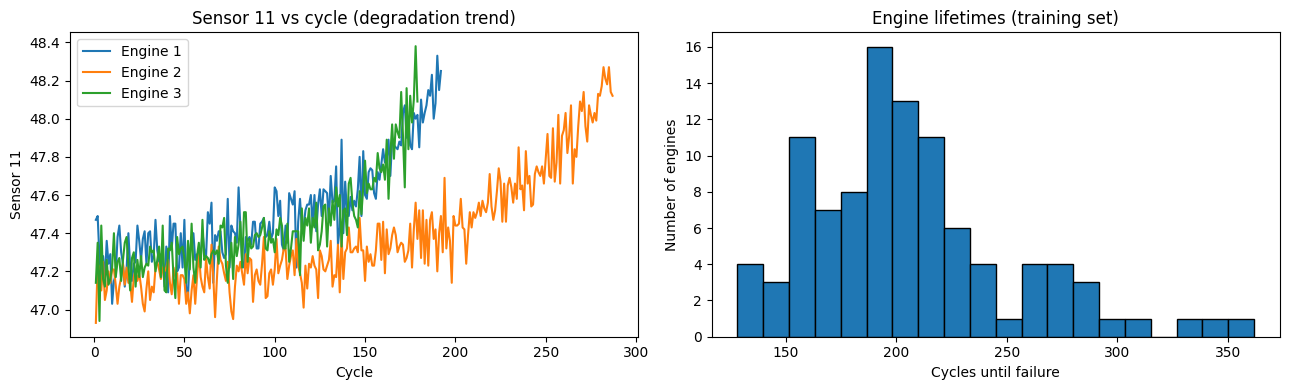

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sensor trend for a few engines: the readings drift as the engine wears out
for eng in [1, 2, 3]:
    d = train[train["unit"] == eng]
    axes[0].plot(d["cycle"], d["s11"], label=f"Engine {eng}")
axes[0].set_title("Sensor 11 vs cycle (degradation trend)")
axes[0].set_xlabel("Cycle")
axes[0].set_ylabel("Sensor 11")
axes[0].legend()

# How long do the training engines live?
lifetimes = train.groupby("unit")["cycle"].max()
axes[1].hist(lifetimes, bins=20, edgecolor="black")
axes[1].set_title("Engine lifetimes (training set)")
axes[1].set_xlabel("Cycles until failure")
axes[1].set_ylabel("Number of engines")

plt.tight_layout()
plt.show()

## 4. Preprocessing

- Remove sensors that never change (they carry no information). The 3 operating settings also barely change in FD001.
- Scale the remaining 14 sensors to the range 0 to 1. **The scaler is fitted on training data only** (no leakage).

In [4]:
# Check which sensors are constant
sensor_cols = [f"s{i}" for i in range(1, 22)]
std = train[sensor_cols].std().round(5)
print("Standard deviation of each sensor (near 0 means useless):")
print(std.to_string())

# Keep only the informative sensors
FEATURES = [c for c in sensor_cols if std[c] > 0.01]
print("\nSensors kept (" + str(len(FEATURES)) + "):", FEATURES)

# Scale to 0-1 (fit on train only)
scaler = MinMaxScaler()
train[FEATURES] = scaler.fit_transform(train[FEATURES])
test[FEATURES] = scaler.transform(test[FEATURES])

Standard deviation of each sensor (near 0 means useless):
s1      0.00000
s2      0.50005
s3      6.13115
s4      9.00060
s5      0.00000
s6      0.00139
s7      0.88509
s8      0.07099
s9     22.08288
s10     0.00000
s11     0.26709
s12     0.73755
s13     0.07192
s14    19.07618
s15     0.03751
s16     0.00000
s17     1.54876
s18     0.00000
s19     0.00000
s20     0.18075
s21     0.10825

Sensors kept (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


## 5. Baseline models (Linear Regression and Random Forest)

These look at **one moment in time**. To reduce sensor noise we also add a rolling average of the last 5 cycles for each sensor.

In [5]:
def add_rolling_means(df, window=5):
    df = df.copy()
    for c in FEATURES:
        df[c + "_rm"] = df.groupby("unit")[c].transform(lambda x: x.rolling(window, min_periods=1).mean())
    return df

train_tab = add_rolling_means(train)
test_tab = add_rolling_means(test)

TAB_FEATURES = FEATURES + [c + "_rm" for c in FEATURES]

X_train_tab = train_tab[TAB_FEATURES].values
y_train_tab = train_tab["RUL_capped"].values

# For each test engine, use only its LAST row (the latest state)
X_test_tab = test_tab.groupby("unit").tail(1)[TAB_FEATURES].values

# Model 1: Linear Regression
lin = LinearRegression()
lin.fit(X_train_tab, y_train_tab)
pred_lin = np.clip(lin.predict(X_test_tab), 0, RUL_CAP)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_tab, y_train_tab)
pred_rf = np.clip(rf.predict(X_test_tab), 0, RUL_CAP)

print("Baseline models trained.")

Baseline models trained.


## 6. Build sliding windows for the LSTM

The LSTM does not see one row. It sees the **last 30 cycles** of an engine, so it can learn the *trend*.

- Input shape: (30 cycles, 14 sensors)
- Target: the (capped) RUL at the last cycle of the window
- Validation split is done **by engine** (not by row), so the same engine is never in both train and validation.

In [6]:
def make_train_windows(df, units, window=WINDOW):
    X, y = [], []
    for u in units:
        d = df[df["unit"] == u]
        values = d[FEATURES].values
        target = d["RUL_capped"].values
        for i in range(window, len(values) + 1):
            X.append(values[i - window:i])
            y.append(target[i - 1])
    return np.array(X, dtype="float32"), np.array(y, dtype="float32")

# Split engines 80% train / 20% validation
units = train["unit"].unique()
np.random.shuffle(units)
split = int(0.8 * len(units))
train_units, val_units = units[:split], units[split:]

X_tr, y_tr = make_train_windows(train, train_units)
X_val, y_val = make_train_windows(train, val_units)

# Test set: the last 30 cycles of each test engine (pad if an engine is shorter)
def last_window(values, window=WINDOW):
    if len(values) < window:
        pad = np.repeat(values[:1], window - len(values), axis=0)
        values = np.vstack([pad, values])
    return values[-window:]

X_test = np.array([last_window(test[test["unit"] == u][FEATURES].values)
                   for u in sorted(test["unit"].unique())], dtype="float32")

print("Train windows     :", X_tr.shape, "from", len(train_units), "engines")
print("Validation windows:", X_val.shape, "from", len(val_units), "engines")
print("Test windows      :", X_test.shape)

Train windows     : (14020, 30, 14) from 80 engines
Validation windows: (3711, 30, 14) from 20 engines
Test windows      : (100, 30, 14)


## 7. Build and train the LSTM

Two LSTM layers with dropout, then a small Dense layer.
**Important:** we train on RUL / 125 (values between 0 and 1). Big target values (0 to 125) can make an LSTM get stuck predicting one constant number. After training we multiply the output by 125 to get cycles back.

In [7]:
model = Sequential([
    Input(shape=(WINDOW, len(FEATURES))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1),
])

model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss="mse")
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, verbose=1),
]

history = model.fit(
    X_tr, y_tr / RUL_CAP,                       # scaled target (0 to 1)
    validation_data=(X_val, y_val / RUL_CAP),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
    verbose=2,
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
220/220 - 8s - 35ms/step - loss: 0.0493 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 2/60
220/220 - 5s - 20ms/step - loss: 0.0214 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 3/60
220/220 - 6s - 25ms/step - loss: 0.0174 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 4/60
220/220 - 5s - 22ms/step - loss: 0.0158 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 5/60
220/220 - 5s - 23ms/step - loss: 0.0149 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 6/60
220/220 - 5s - 22ms/step - loss: 0.0145 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 7/60
220/220 - 8s - 37ms/step - loss: 0.0134 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 8/60
220/220 - 5s - 21ms/step - loss: 0.0132 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 9/60
220/220 - 5s - 24ms/step - loss: 0.0126 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 10/60
220/220 - 4s - 20ms/step - loss: 0.0123 - val_loss: 0.0117 - learning_rate: 0.0010
Epoch 11/60
220/220 - 5s - 22ms/step - loss: 0.0123 - val_l

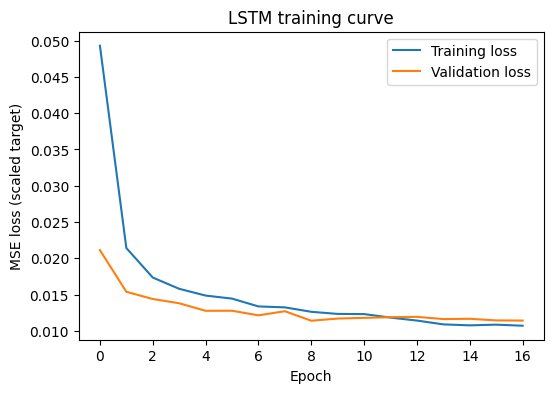

Std of validation predictions: 39.96 (should be well above 5)


In [8]:
# Learning curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("LSTM training curve")
plt.xlabel("Epoch")
plt.ylabel("MSE loss (scaled target)")
plt.legend()
plt.show()

# Sanity check: the LSTM must give DIFFERENT predictions for different engines
val_pred = model.predict(X_val, verbose=0).flatten() * RUL_CAP
print("Std of validation predictions:", round(float(val_pred.std()), 2), "(should be well above 5)")

## 8. Evaluate all models on the 100 test engines

- **RMSE**: average size of the error in cycles (lower is better)
- **MAE**: average absolute error
- **R2**: 1 is perfect, 0 means no better than guessing the average
- **NASA score**: like an error, but predicting too much life left (late prediction) is punished more, because that is the dangerous mistake

In [9]:
def nasa_score(y_true, y_pred):
    d = y_pred - y_true
    return np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1))

pred_lstm = np.clip(model.predict(X_test, verbose=0).flatten() * RUL_CAP, 0, RUL_CAP)

predictions = {
    "Linear Regression": pred_lin,
    "Random Forest": pred_rf,
    "LSTM": pred_lstm,
}

rows = []
for name, pred in predictions.items():
    rows.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(rul_test, pred)),
        "MAE": mean_absolute_error(rul_test, pred),
        "R2": r2_score(rul_test, pred),
        "NASA Score": nasa_score(rul_test, pred),
    })

results = pd.DataFrame(rows).sort_values("RMSE").round(2).reset_index(drop=True)
results.to_csv("results.csv", index=False)
results

,Model,RMSE,MAE,R2,NASA Score
0,LSTM,14.71,11.04,0.87,301.40
1,Random Forest,19.16,13.99,0.79,1145.05
2,Linear Regression,21.71,17.33,0.73,1329.77


## 9. Result plots

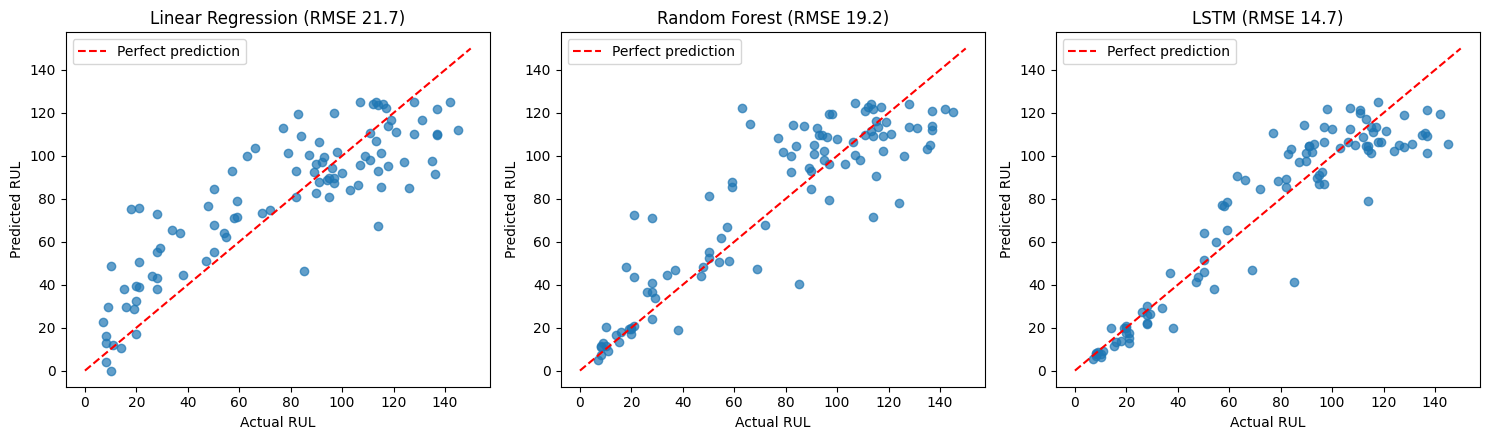

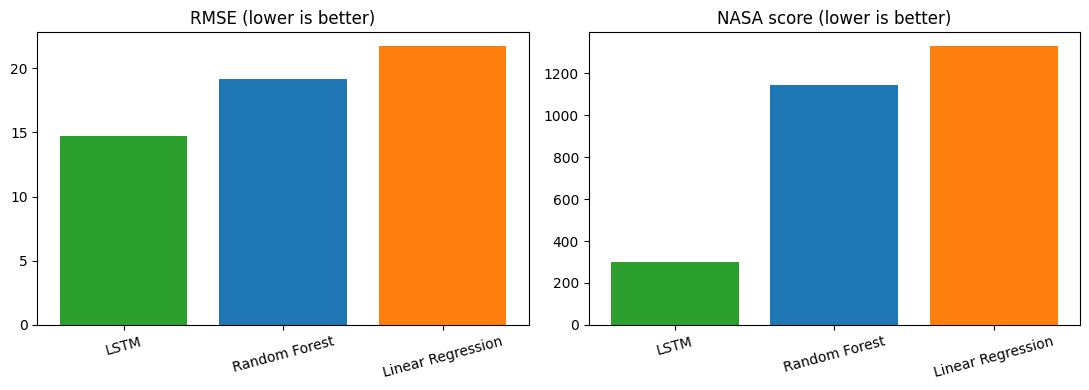

In [10]:
# Predicted vs actual for each model (points near the red line = good)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pred) in zip(axes, predictions.items()):
    ax.scatter(rul_test, pred, alpha=0.7)
    lim = [0, max(rul_test.max(), RUL_CAP) + 5]
    ax.plot(lim, lim, "r--", label="Perfect prediction")
    rmse = np.sqrt(mean_squared_error(rul_test, pred))
    ax.set_title(f"{name} (RMSE {rmse:.1f})")
    ax.set_xlabel("Actual RUL")
    ax.set_ylabel("Predicted RUL")
    ax.legend()
plt.tight_layout()
plt.show()

# Compare the models
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(results["Model"], results["RMSE"], color=["tab:green", "tab:blue", "tab:orange"][:len(results)])
axes[0].set_title("RMSE (lower is better)")
axes[1].bar(results["Model"], results["NASA Score"], color=["tab:green", "tab:blue", "tab:orange"][:len(results)])
axes[1].set_title("NASA score (lower is better)")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

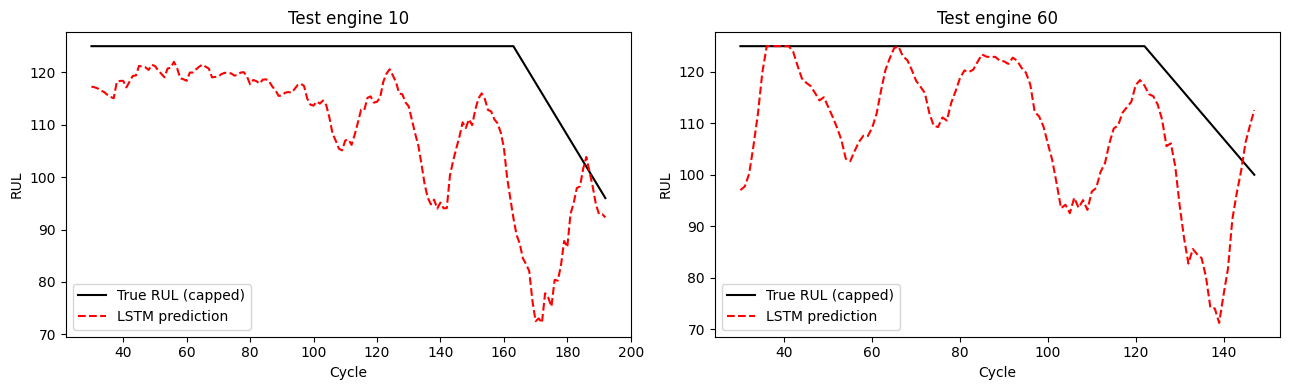

In [11]:
# RUL over time for 2 test engines: does the LSTM prediction follow the truth?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, eng in zip(axes, [10, 60]):
    values = test[test["unit"] == eng][FEATURES].values
    n = len(values)
    windows = np.array([values[i - WINDOW:i] for i in range(WINDOW, n + 1)], dtype="float32")
    pred = np.clip(model.predict(windows, verbose=0).flatten() * RUL_CAP, 0, RUL_CAP)
    cycles = np.arange(WINDOW, n + 1)
    true_rul = np.clip(n + rul_test[eng - 1] - cycles, 0, RUL_CAP)   # true RUL at each cycle
    ax.plot(cycles, true_rul, "k-", label="True RUL (capped)")
    ax.plot(cycles, pred, "r--", label="LSTM prediction")
    ax.set_title(f"Test engine {eng}")
    ax.set_xlabel("Cycle")
    ax.set_ylabel("RUL")
    ax.legend()
plt.tight_layout()
plt.show()

## 10. Maintenance alert 

A simple use of the model: flag every engine whose predicted RUL is below 30 cycles, so it can be repaired **before** it fails.

In [12]:
ALERT = 30
alerts = pd.DataFrame({
    "Engine": sorted(test["unit"].unique()),
    "Predicted RUL": pred_lstm.round(1),
    "True RUL": rul_test,
})
urgent = alerts[alerts["Predicted RUL"] < ALERT].sort_values("Predicted RUL")
print(f"{len(urgent)} engines need maintenance soon (predicted RUL < {ALERT} cycles):")
urgent

26 engines need maintenance soon (predicted RUL < 30 cycles):


,Engine,Predicted RUL,True RUL
33,34,5.200000,7
41,42,6.500000,10
80,81,6.900000,8
75,76,7.500000,10
67,68,7.900000,8
30,31,8.000000,8
81,82,8.800000,9
34,35,9.200000,11
55,56,11.600000,15
48,49,12.700000,21
